# 02 - Exploration Fichiers CSV

Exploration des fichiers CSV pour l'analyse de satisfaction.

**Architecture:**
- Données CSV → `dataSetAirlines/`
- Code Python → Ce notebook

## 1. Imports et Configuration

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration
PROJECT_ROOT = Path("/home/esprit/airlLines_Project")
CSV_DIR = PROJECT_ROOT / "dataSetAirlines"

# Configuration visualisation
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Configuration chargée")
print(f"📂 CSV: {CSV_DIR}")

✅ Configuration chargée
📂 CSV: /home/esprit/airlLines_Project/dataSetAirlines


## 2. Liste des fichiers CSV

In [25]:
csv_files = list(CSV_DIR.glob("*.csv"))

print(f"📂 {len(csv_files)} fichiers CSV trouvés:\n")

for i, csv_file in enumerate(sorted(csv_files), 1):
    size_mb = csv_file.stat().st_size / (1024 * 1024)
    print(f"{i}. {csv_file.name:40s} ({size_mb:6.1f} MB)")

📂 11 fichiers CSV trouvés:

1. Airline_Scrapped_Review.csv              (   3.4 MB)
2. Calendar.csv                             (   0.1 MB)
3. Customer_Flight_Activity.csv             (  10.6 MB)
4. Customer_Loyalty_History.csv             (   1.7 MB)
5. Customer_comment.csv                     (   3.2 MB)
6. Passanger_booking_data.csv               (   3.0 MB)
7. Survey_data_Inflight_Satisfaction_Score.csv (  13.9 MB)
8. airline_passenger_satisfaction.csv       (  12.3 MB)
9. airline_ticket_prices_dataset.csv        (   0.0 MB)
10. airlines_flights_data.csv                (  23.8 MB)
11. airlines_reviews.csv                     (   7.6 MB)


## 3. airline_passenger_satisfaction.csv - Dataset principal

In [26]:
# Chargement
df_satisfaction = pd.read_csv(CSV_DIR / "airline_passenger_satisfaction.csv")

print(f"📊 Shape: {df_satisfaction.shape}")
print(f"\nColonnes: {list(df_satisfaction.columns)}")
print(f"\nValeurs manquantes:\n{df_satisfaction.isnull().sum().sum()}")
print(f"\nAperçu:")
display(df_satisfaction.head())

📊 Shape: (129880, 24)

Colonnes: ['ID', 'Gender', 'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling', 'Satisfaction']

Valeurs manquantes:
393

Aperçu:


,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


## 4. Distribution des variables clés

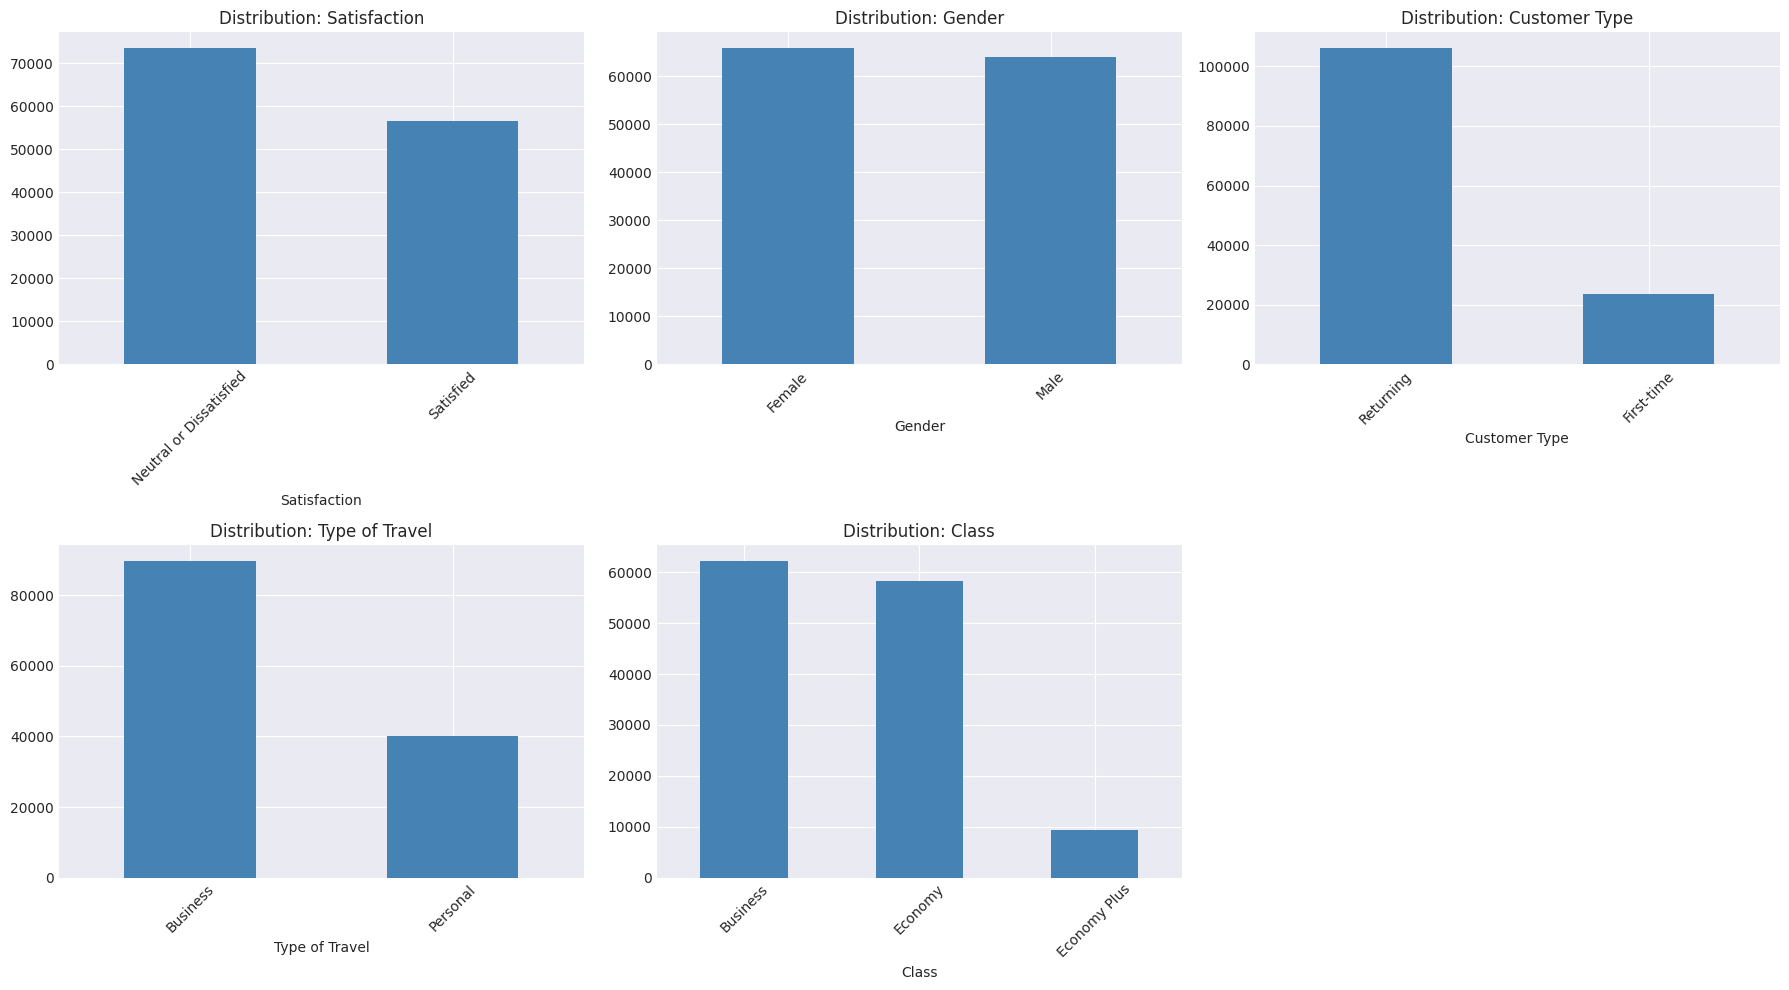

In [27]:
# Variables catégorielles
categorical_cols = ['Satisfaction', 'Gender', 'Customer Type', 'Type of Travel', 'Class']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df_satisfaction[col].value_counts()
    counts.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution: {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Dernier subplot vide
axes[-1].axis('off')

plt.tight_layout()
plt.show()

## 5. Scores de service (1-5)

In [28]:
# Chargement
df_reviews = pd.read_csv(CSV_DIR / "airlines_reviews.csv")

print(f"📊 Shape: {df_reviews.shape}")
print(f"\nColonnes: {list(df_reviews.columns)}")
print(f"\nAperçu:")
display(df_reviews.head())

# Distribution des notes
print(f"\n📊 Distribution Overall Rating:")
print(df_reviews['Overall Rating'].value_counts().sort_index())

📊 Shape: (8100, 17)

Colonnes: ['Title', 'Name', 'Review Date', 'Airline', 'Verified', 'Reviews', 'Type of Traveller', 'Month Flown', 'Route', 'Class', 'Seat Comfort', 'Staff Service', 'Food & Beverages', 'Inflight Entertainment', 'Value For Money', 'Overall Rating', 'Recommended']

Aperçu:


,Title,Name,Review Date,Airline,Verified,Reviews,Type of Traveller,Month Flown,Route,Class,Seat Comfort,Staff Service,Food & Beverages,Inflight Entertainment,Value For Money,Overall Rating,Recommended
0,Flight was amazing,Alison Soetantyo,2024-03-01,Singapore Airlines,True,Flight was amazing. The crew onboard this fl...,Solo Leisure,December 2023,Jakarta to Singapore,Business Class,4,4,4,4,4,9,yes
1,seats on this aircraft are dreadful,Robert Watson,2024-02-21,Singapore Airlines,True,Booking an emergency exit seat still meant h...,Solo Leisure,February 2024,Phuket to Singapore,Economy Class,5,3,4,4,1,3,no
2,Food was plentiful and tasty,S Han,2024-02-20,Singapore Airlines,True,Excellent performance on all fronts. I would...,Family Leisure,February 2024,Siem Reap to Singapore,Economy Class,1,5,2,1,5,10,yes
3,“how much food was available,D Laynes,2024-02-19,Singapore Airlines,True,Pretty comfortable flight considering I was f...,Solo Leisure,February 2024,Singapore to London Heathrow,Economy Class,5,5,5,5,5,10,yes
4,“service was consistently good”,A Othman,2024-02-19,Singapore Airlines,True,The service was consistently good from start ...,Family Leisure,February 2024,Singapore to Phnom Penh,Economy Class,5,5,5,5,5,10,yes



📊 Distribution Overall Rating:
Overall Rating
1     1808
2      692
3      522
4      381
5      436
6      346
7      509
8      742
9     1054
10    1610
Name: count, dtype: int64


## 6. airlines_reviews.csv - Avis textuels

In [29]:
# Avis positifs (Rating >= 8)
positive_reviews = df_reviews[df_reviews['Overall Rating'] >= 8]['Reviews'].dropna().head(3)

# Avis négatifs (Rating <= 4)
negative_reviews = df_reviews[df_reviews['Overall Rating'] <= 4]['Reviews'].dropna().head(3)

print("📝 Exemple d'avis POSITIFS (Rating >= 8):\n")
for i, review in enumerate(positive_reviews, 1):
    print(f"\n{i}. {review[:200]}..." if len(review) > 200 else f"\n{i}. {review}")

print("\n\n📝 Exemple d'avis NÉGATIFS (Rating <= 4):\n")
for i, review in enumerate(negative_reviews, 1):
    print(f"\n{i}. {review[:200]}..." if len(review) > 200 else f"\n{i}. {review}")

📝 Exemple d'avis POSITIFS (Rating >= 8):


1.   Flight was amazing. The crew onboard this flight were very welcoming, and gave a good atmosphere. The crew serving my aisle goes by the initial “G”. She was very kind & helpful. Gave my mom a bday c...

2.   Excellent performance on all fronts. I would definitely choose to use this airline again. The aircraft is well-maintained and the staff well-trained on hospitality. Food was plentiful and tasty.

3.  Pretty comfortable flight considering I was flying in economy class in one of the older aircraft in their fleet which is still kept in relatively good condition. The economy class cabin was in a 3-3-...


📝 Exemple d'avis NÉGATIFS (Rating <= 4):


1.   Booking an emergency exit seat still meant huge discomfort in a seat far too narrow and poor padding meaning back ache in 90 minute flight. The seats on this aircraft are dreadful. The headphones an...

2.  This flight was over six hours long on a B737 MAX8. I booked an emergency exit row s

## 7. Exemple d'avis textuels

In [30]:
# Avis positifs (Rating >= 8)
positive_reviews = df_reviews[df_reviews['Overall Rating'] >= 8]['Reviews'].dropna().head(3)

# Avis négatifs (Rating <= 4)
negative_reviews = df_reviews[df_reviews['Overall Rating'] <= 4]['Reviews'].dropna().head(3)

print("📝 Exemple d'avis POSITIFS (Rating >= 8):\n")
for i, review in enumerate(positive_reviews, 1):
    print(f"\n{i}. {review[:200]}..." if len(review) > 200 else f"\n{i}. {review}")

print("\n\n📝 Exemple d'avis NÉGATIFS (Rating <= 4):\n")
for i, review in enumerate(negative_reviews, 1):
    print(f"\n{i}. {review[:200]}..." if len(review) > 200 else f"\n{i}. {review}")

📝 Exemple d'avis POSITIFS (Rating >= 8):


1.   Flight was amazing. The crew onboard this flight were very welcoming, and gave a good atmosphere. The crew serving my aisle goes by the initial “G”. She was very kind & helpful. Gave my mom a bday c...

2.   Excellent performance on all fronts. I would definitely choose to use this airline again. The aircraft is well-maintained and the staff well-trained on hospitality. Food was plentiful and tasty.

3.  Pretty comfortable flight considering I was flying in economy class in one of the older aircraft in their fleet which is still kept in relatively good condition. The economy class cabin was in a 3-3-...


📝 Exemple d'avis NÉGATIFS (Rating <= 4):


1.   Booking an emergency exit seat still meant huge discomfort in a seat far too narrow and poor padding meaning back ache in 90 minute flight. The seats on this aircraft are dreadful. The headphones an...

2.  This flight was over six hours long on a B737 MAX8. I booked an emergency exit row s

## 8. Customer_comment.csv - Sentiments étiquetés

In [31]:
# Chargement
df_comments = pd.read_csv(CSV_DIR / "Customer_comment.csv")

print(f"📊 Shape: {df_comments.shape}")
print(f"\nColonnes: {list(df_comments.columns)}")

# Distribution des sentiments
sentiment_counts = df_comments['sentiments'].value_counts()
print(f"\n📊 Distribution des sentiments:")
for sentiment, count in sentiment_counts.items():
    pct = count / len(df_comments) * 100
    print(f"   {sentiment}: {count:,} ({pct:.1f}%)")

📊 Shape: (9424, 17)

Colonnes: ['id', 'flight_number', 'origin_station_code', 'destination_station_code', 'scheduled_departure_date', 'arrival_delay_group', 'departure_delay_group', 'entity', 'verbatim_text', 'seat_factor_band', 'ques_verbatim_text', 'loyalty_program_level', 'fleet_type_description', 'fleet_usage', 'response_group', 'sentiments', 'transformed_text']

📊 Distribution des sentiments:
   Neutral: 9,307 (98.8%)
   Negative: 117 (1.2%)


## 9. Résumé

In [32]:
print("""\n
╔════════════════════════════════════════════════════════════╗
║            ✅ EXPLORATION CSV TERMINÉE                         ║
╚════════════════════════════════════════════════════════════╝

📂 Fichiers explorés:
   • airline_passenger_satisfaction.csv (129,880 lignes)
   • airlines_reviews.csv (8,100 lignes)
   • Customer_comment.csv (9,424 lignes)

🔍 Types de données:
   • Scores quantitatifs (1-5)
   • Avis textuels (bruts et transformés)
   • Sentiments étiquetés (positive/negative/neutral)

📝 Prochaine étape:
   • 03_ml_classification.ipynb - Modèle ML de classification
""")



╔════════════════════════════════════════════════════════════╗
║            ✅ EXPLORATION CSV TERMINÉE                         ║
╚════════════════════════════════════════════════════════════╝

📂 Fichiers explorés:
   • airline_passenger_satisfaction.csv (129,880 lignes)
   • airlines_reviews.csv (8,100 lignes)
   • Customer_comment.csv (9,424 lignes)

🔍 Types de données:
   • Scores quantitatifs (1-5)
   • Avis textuels (bruts et transformés)
   • Sentiments étiquetés (positive/negative/neutral)

📝 Prochaine étape:
   • 03_ml_classification.ipynb - Modèle ML de classification

